In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import torch

from src.config import FIG_DIR
from src.features import TARGET
from src.train_torch import build_mlp, main as train_torch_main, train_model

out = train_torch_main()
model, history = out["model"], out["history"]
train, val, test = out["train"], out["val"], out["test"]
train_t, val_t, test_t = out["train_t"], out["val_t"], out["test_t"]
feats = out["feats"]
x_scaler, y_scaler = out["x_scaler"], out["y_scaler"]

 train:  48,599 rows   2019-01-15 -> 2024-07-31
   val:   8,760 rows   2024-07-31 -> 2025-07-31
  test:   8,733 rows   2025-07-31 -> 2026-07-31
epoch   0  train 0.1774  val 0.0910  val MAE 734 MW
epoch   5  train 0.0432  val 0.0513  val MAE 545 MW
epoch  10  train 0.0346  val 0.0399  val MAE 476 MW
epoch  15  train 0.0316  val 0.0372  val MAE 451 MW
epoch  20  train 0.0295  val 0.0355  val MAE 446 MW
epoch  25  train 0.0286  val 0.0336  val MAE 432 MW
epoch  30  train 0.0276  val 0.0332  val MAE 427 MW
epoch  35  train 0.0268  val 0.0321  val MAE 417 MW
epoch  40  train 0.0263  val 0.0320  val MAE 418 MW
epoch  45  train 0.0257  val 0.0319  val MAE 420 MW
epoch  50  train 0.0254  val 0.0328  val MAE 426 MW
epoch  55  train 0.0254  val 0.0307  val MAE 416 MW
epoch  59  train 0.0246  val 0.0318  val MAE 425 MW

best epoch: 51   val MAE 405 MW


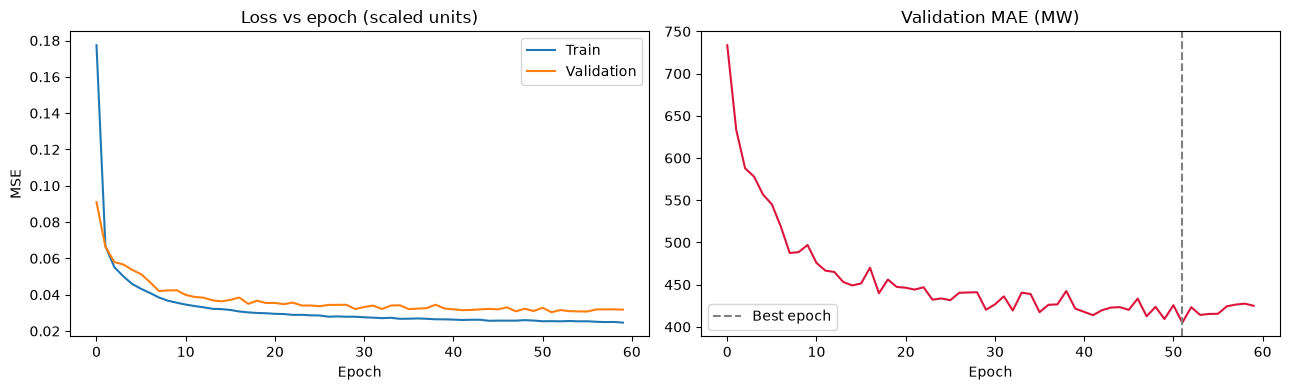

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Validation")
axes[0].set_title("Loss vs epoch (scaled units)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE"); axes[0].legend()

axes[1].plot(history["val_mae_mw"], color="crimson")
axes[1].axvline(int(np.argmin(history["val_mae_mw"])), linestyle="--",
                color="grey", label="Best epoch")
axes[1].set_title("Validation MAE (MW)")
axes[1].set_xlabel("Epoch"); axes[1].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / "09_learning_curve_epochs.png", dpi=130)
plt.show()

epoch   0  train 0.6000  val 0.4784  val MAE 1,793 MW
epoch   5  train 0.0765  val 0.1306  val MAE 901 MW
epoch  10  train 0.0490  val 0.1320  val MAE 892 MW
epoch  15  train 0.0395  val 0.1293  val MAE 880 MW
epoch  20  train 0.0339  val 0.1246  val MAE 861 MW
epoch  25  train 0.0292  val 0.1190  val MAE 844 MW
epoch  30  train 0.0257  val 0.1102  val MAE 812 MW
epoch  35  train 0.0229  val 0.1032  val MAE 779 MW
epoch  40  train 0.0204  val 0.1012  val MAE 770 MW


epoch  45  train 0.0185  val 0.0942  val MAE 746 MW
epoch  50  train 0.0169  val 0.0951  val MAE 745 MW
epoch  55  train 0.0156  val 0.0946  val MAE 743 MW
epoch  60  train 0.0144  val 0.0927  val MAE 736 MW
epoch  65  train 0.0136  val 0.0935  val MAE 741 MW
epoch  70  train 0.0134  val 0.0931  val MAE 741 MW
epoch  75  train 0.0128  val 0.0974  val MAE 755 MW
epoch  80  train 0.0116  val 0.0974  val MAE 757 MW
epoch  85  train 0.0109  val 0.0958  val MAE 746 MW
epoch  90  train 0.0103  val 0.0942  val MAE 742 MW
epoch  95  train 0.0097  val 0.0988  val MAE 757 MW
epoch 100  train 0.0093  val 0.1003  val MAE 762 MW
epoch 105  train 0.0092  val 0.0984  val MAE 754 MW
epoch 110  train 0.0085  val 0.1019  val MAE 771 MW
epoch 115  train 0.0081  val 0.1049  val MAE 782 MW
epoch 120  train 0.0079  val 0.1056  val MAE 779 MW
epoch 125  train 0.0078  val 0.1070  val MAE 791 MW
epoch 130  train 0.0076  val 0.1066  val MAE 784 MW
epoch 135  train 0.0072  val 0.1090  val MAE 789 MW
epoch 140  t

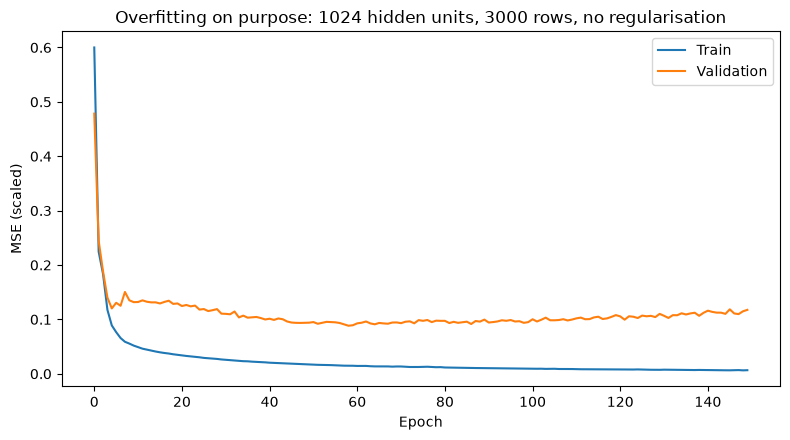

In [3]:

small = train.iloc[-3000:]
small_t = (
    torch.tensor(x_scaler.transform(small[feats]), dtype=torch.float32),
    torch.tensor(y_scaler.transform(small[[TARGET]]), dtype=torch.float32),
)

overfit_model = build_mlp(len(feats), n_hidden=1024, dropout=0.0)
overfit_hist = train_model(overfit_model, small_t, val_t, y_scaler,
                           epochs=150, weight_decay=0.0)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(overfit_hist["train_loss"], label="Train")
ax.plot(overfit_hist["val_loss"], label="Validation")
ax.set_title("Overfitting on purpose: 1024 hidden units, 3000 rows, no regularisation")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE (scaled)"); ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "10_overfitting.png", dpi=130)
plt.show()

n= 2,000  train MAE      37  val MAE     961
n= 5,000  train MAE      73  val MAE     568
n=10,000  train MAE     106  val MAE     478
n=20,000  train MAE     145  val MAE     435
n=40,000  train MAE     180  val MAE     407
n=48,599  train MAE     188  val MAE     406


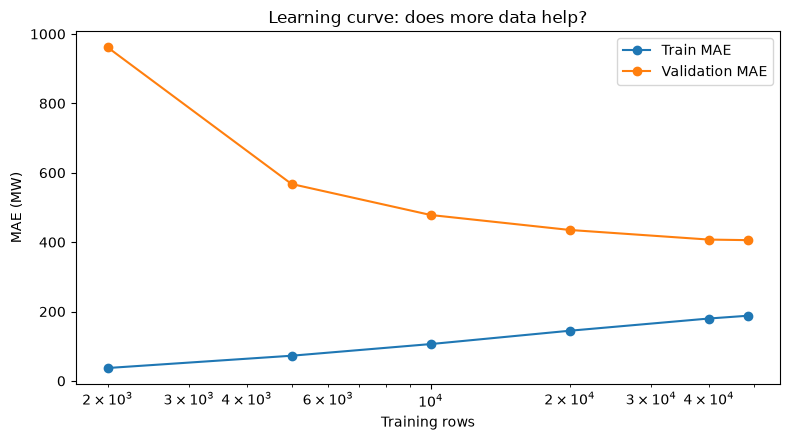

In [4]:
from src.models import build_gbm
from src.evaluate import mae

sizes = [2000, 5000, 10000, 20000, 40000, len(train)]
train_scores, val_scores = [], []

for n in sizes:
    subset = train.iloc[-n:]             
    m = build_gbm().fit(subset[feats], subset[TARGET])
    train_scores.append(mae(subset[TARGET], m.predict(subset[feats])))
    val_scores.append(mae(val[TARGET], m.predict(val[feats])))
    print(f"n={n:>6,}  train MAE {train_scores[-1]:>7,.0f}  val MAE {val_scores[-1]:>7,.0f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sizes, train_scores, marker="o", label="Train MAE")
ax.plot(sizes, val_scores, marker="o", label="Validation MAE")
ax.set_xscale("log")
ax.set_title("Learning curve: does more data help?")
ax.set_xlabel("Training rows"); ax.set_ylabel("MAE (MW)"); ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "11_learning_curve_size.png", dpi=130)
plt.show()

In [5]:
from src.evaluate import results_table, score
from src.models import train_all
from src.config import REPORTS_DIR



sk = train_all()
ridge, gbm = sk["ridge"], sk["gbm"]

model.eval()
with torch.no_grad():
    X_te, y_te = test_t
    mlp_pred = y_scaler.inverse_transform(model(X_te).numpy()).ravel()

rows = [
    score("Naive-24", test[TARGET], test["lag_24"]),
    score("Naive-168", test[TARGET], test["lag_168"]),
    score("Ridge", test[TARGET], ridge.predict(test[feats])),
    score("GradientBoosting", test[TARGET], gbm.predict(test[feats])),
    score("PyTorch MLP", test[TARGET], mlp_pred),
]

final = results_table(rows, baseline_name="Naive-24")
print(final.to_string(index=False))
final.to_csv(REPORTS_DIR / "final_results.csv", index=False)

 train:  48,599 rows   2019-01-15 -> 2024-07-31
   val:   8,760 rows   2024-07-31 -> 2025-07-31
  test:   8,733 rows   2025-07-31 -> 2026-07-31

Validation results (baseline: Naive-24):

           model   MAE_MW  RMSE_MW  MAPE_pct  vs_baseline_pct
GradientBoosting  405.757  554.968     2.322           58.396
           Ridge  630.834  839.950     3.640           35.318
        Naive-24  975.286 1399.683     5.540            0.000
       Naive-168 1500.454 2202.822     8.306          -53.848

Final test results:

           model     MAE_MW    RMSE_MW  MAPE_pct
GradientBoosting 483.234264 669.600538   2.81191
           model   MAE_MW  RMSE_MW  MAPE_pct  vs_baseline_pct
GradientBoosting  483.234  669.601     2.812           53.779
     PyTorch MLP  487.173  659.644     2.878           53.402
           Ridge  691.841  931.951     4.106           33.825
        Naive-24 1045.477 1439.441     6.085            0.000
       Naive-168 1731.380 2406.601     9.837          -65.607


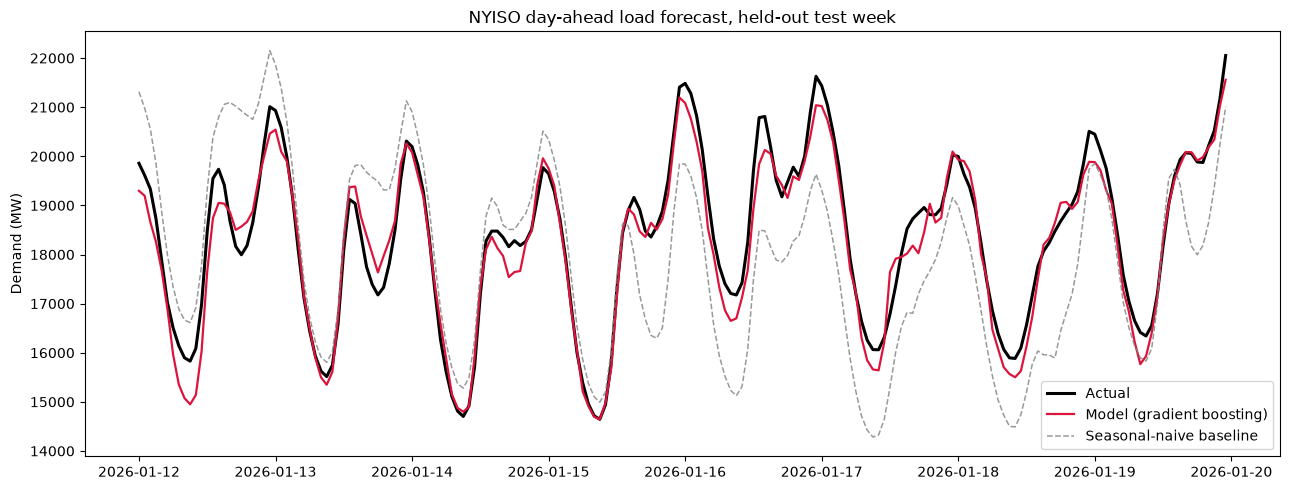

In [6]:
week = test.loc["2026-01-12":"2026-01-19"]    

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(week.index, week[TARGET], color="black", linewidth=2.2, label="Actual")
ax.plot(week.index, gbm.predict(week[feats]), color="crimson",
        linewidth=1.6, label="Model (gradient boosting)")
ax.plot(week.index, week["lag_168"], color="grey", linewidth=1.1,
        linestyle="--", alpha=0.8, label="Seasonal-naive baseline")
ax.set_title("NYISO day-ahead load forecast, held-out test week")
ax.set_ylabel("Demand (MW)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "00_headline.png", dpi=150)
plt.show()